# Drivers 60 — How much open coast does NZ have?
Computed from the LINZ 1:50k mean-high-water coastline (19,082 km incl. all
islands in the NZTM extent) with a definition calibrated against the NZCCD's
expert EXPOSURE field:

**Open coast = geometrically open (a 1 km-radius disc of water reaches the shore
through passages ≥2 km wide — a morphological closing on a 100 m raster of the
coastline itself) AND WHACS mean Hs ≥ 0.75 m at the nearest wave-model point.**

Geometry alone cannot see shelter by offshore islands (inner Hauraki Gulf,
Bay of Islands) or a huge-mouthed harbour (Kaipara); the wave criterion fixes
that. Against the NZCCD's E/S classes the rule recovers 100% of sheltered and
82% of exposed transects (balanced accuracy 91%; geometry alone peaks at 56%).
Sensitivity over closing radius × Hs threshold is tabulated.

In [1]:
import pandas as pd
from drivers import common
STATS = common.DRIVER_DATA / "stats"
if not (STATS / "opencoast_lengths.csv").exists():
    from drivers.opencoast import build; build()
L = pd.read_csv(STATS / "opencoast_lengths.csv")
L[L.scope.isin(["all","island"])][["name","total_km","open_km","open_pct","geom_open_km_R1","geom_open_km_R2","open_km_R2_hs075","open_nzccd_cov_km","open_coastsat_cov_km","open_eroding_km","open_accreting_km","open_stable_km"]]

,name,total_km,open_km,open_pct,geom_open_km_R1,geom_open_km_R2,open_km_R2_hs075,open_nzccd_cov_km,open_coastsat_cov_km,open_eroding_km,open_accreting_km,open_stable_km
0,New Zealand (LINZ MHW extent),19082.2,6096.8,32.0,7134.2,5435.4,4797.5,2057.9,2348.4,738.8,784.1,535.0
1,North Island,8914.8,2885.8,32.4,3240.2,2562.8,2348.5,1366.4,1217.3,418.4,576.0,372.0
2,Other islands,2628.9,819.9,31.2,1072.9,664.4,546.2,0.0,29.9,0.0,0.0,0.0
3,South Island,6696.4,2210.8,33.0,2606.9,2089.1,1804.4,677.8,1087.1,314.0,203.8,160.1
4,Stewart Island,842.1,180.4,21.4,214.2,119.1,98.3,13.7,14.1,6.5,4.3,3.0


**Headline: ~6,100 km of open coast (32% of the coastline)** — North Island
2,890 km, South Island 2,210 km, Stewart Island 180 km, other islands 820 km.
Sensitivity range 4,800 km (R = 2 km) to 6,600 km (Hs ≥ 0.5 m). The NZCCD maps
2,060 km of it (34%), CoastSat 2,350 km (39%); of the NZCCD-mapped open coast,
739 km is eroding (WLR < −0.1 m/yr), 784 km accreting, 535 km stable.

## By region (region = nearest NZCCD transect within 30 km)

In [2]:
L[L.scope=="region"].sort_values("open_km", ascending=False)[["name","total_km","open_km","open_pct","open_nzccd_cov_km","open_eroding_km","open_accreting_km"]].reset_index(drop=True)

,name,total_km,open_km,open_pct,open_nzccd_cov_km,open_eroding_km,open_accreting_km
0,Northland,3699.0,894.7,24.2,342.0,74.3,176.7
1,Offshore/other,3137.2,771.9,24.6,0.0,0.0,0.0
2,Southland,2185.1,617.0,28.2,120.2,24.9,64.7
3,West Coast,572.1,507.5,88.7,223.6,112.3,62.0
4,Waikato,1651.8,465.5,28.2,130.7,38.4,59.9
5,Canterbury,825.0,407.6,49.4,186.9,121.7,39.0
6,Wellington,530.9,383.6,72.2,120.4,42.2,43.0
7,Otago,613.4,336.9,54.9,146.5,57.8,36.7
8,Hawkes Bay,400.9,321.3,80.1,115.0,35.1,49.2
9,Bay of Plenty,787.0,291.3,37.0,137.8,35.5,72.9


## Sensitivity & validation vs NZCCD EXPOSURE

In [3]:
pd.read_csv(STATS / "opencoast_sensitivity.csv").sort_values("balanced_acc", ascending=False).head(12).reset_index(drop=True)

,R_km,hs_min,n_E,n_S,E_open_pct,S_enclosed_pct,balanced_acc,open_km
0,1,0.8,21741,828,82.1,100.0,91.0,6096.8
1,2,0.8,21741,828,74.0,100.0,87.0,4797.5
2,3,0.8,21741,828,67.9,100.0,83.9,4127.3
3,1,0.5,21741,828,86.7,79.0,82.9,6616.6
4,1,1.0,21741,828,62.2,100.0,81.1,4967.6
5,2,0.5,21741,828,78.4,81.2,79.8,5147.4
6,5,0.8,21741,828,56.7,100.0,78.3,3307.8
7,2,1.0,21741,828,55.9,100.0,78.0,3894.6
8,3,0.5,21741,828,72.0,81.5,76.8,4416.0
9,3,1.0,21741,828,51.1,100.0,75.5,3342.9


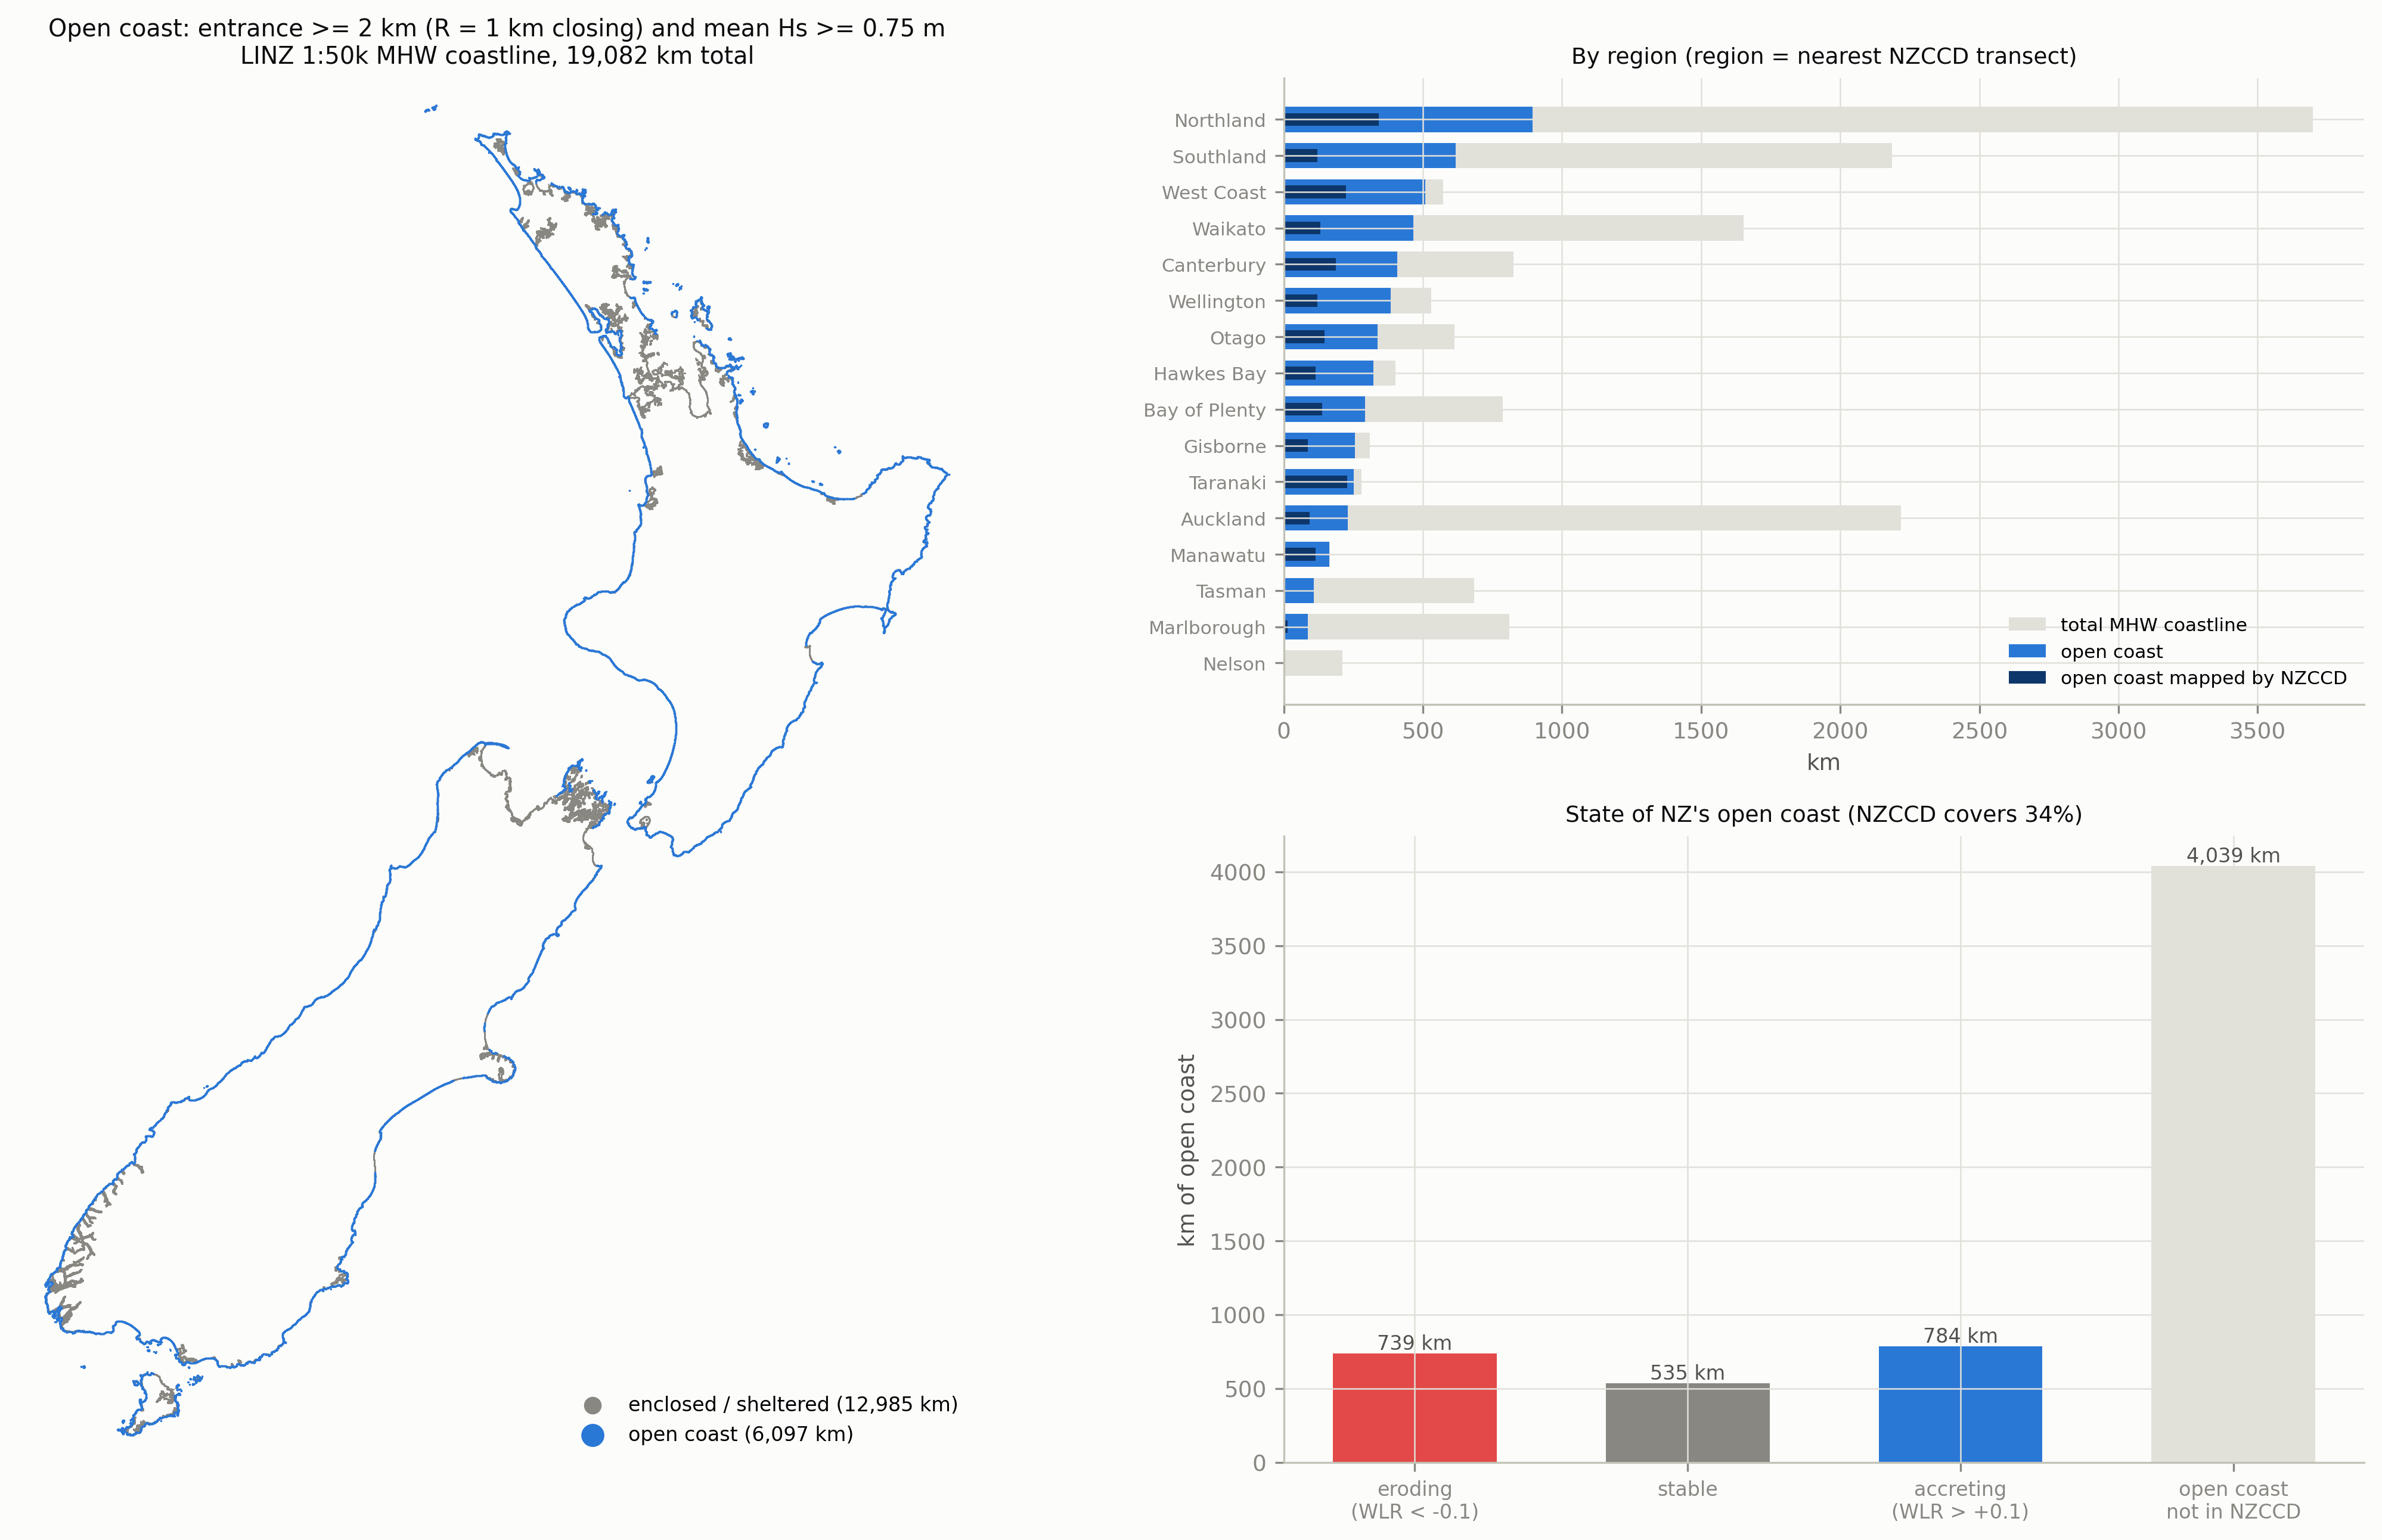

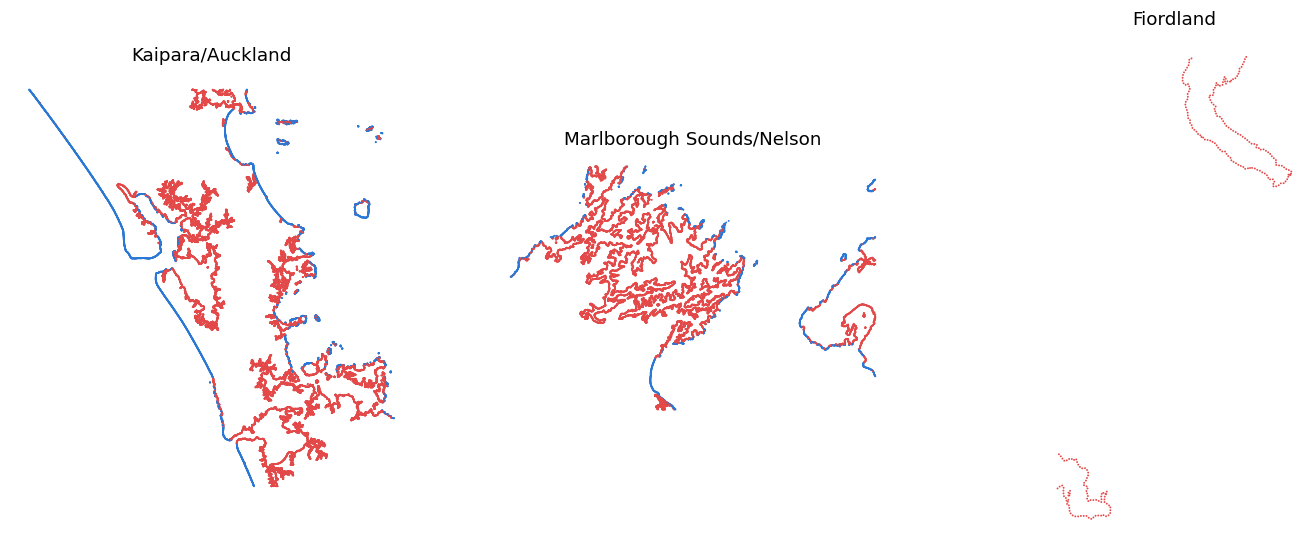

In [4]:
from IPython.display import Image, display
from drivers.figures import FIGS
if not (FIGS / "F9_opencoast.png").exists():
    from drivers.figures import run_extra; run_extra()
display(Image(str(FIGS / "F9_opencoast.png"), width=1000))
display(Image(str(common.QA_DIR / "opencoast_R2_zoom.png"), width=1000))